# PitIQ — EDA: Lap Features Dataset

**Input:** `data/features/lap_features.parquet` — 108,257 clean laps across 5 seasons (2021–2025), 39 columns.  
**Purpose:** Validate that the feature dataset is sensible before training the XGBoost lap-time model.

**Checks covered:**
1. Missing data audit
2. Compound usage frequency
3. Tire degradation curves (LapTimeCorrected vs tire_age) — the core XGBoost signal
4. Lap time distributions per circuit
5. Wet vs dry lap time deltas

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'figure.facecolor': '#0a0a0f',
    'axes.facecolor':   '#12121a',
    'axes.edgecolor':   '#2a2a3d',
    'axes.labelcolor':  '#f0f0f5',
    'xtick.color':      '#8888aa',
    'ytick.color':      '#8888aa',
    'text.color':       '#f0f0f5',
    'grid.color':       '#2a2a3d',
    'grid.linestyle':   '--',
    'legend.facecolor': '#1a1a26',
    'legend.edgecolor': '#2a2a3d',
    'figure.dpi':       120,
})

COMPOUND_COLORS = {
    'SOFT':         '#E8002D',
    'MEDIUM':       '#FFF200',
    'HARD':         '#e0e0e0',
    'INTERMEDIATE': '#43B02A',
    'WET':          '#0067FF',
}

REPO_ROOT = Path('..').resolve()
df = pd.read_parquet(REPO_ROOT / 'data/features/lap_features.parquet')

# Drop rows where Compound is 'None' or 'nan' (string literals from FastF1 source gaps).
# These 765 rows (~0.7%) have no usable compound signal and would pollute compound-split plots.
df = df[~df['Compound'].isin(['None', 'nan'])].copy()

print(f'Loaded {len(df):,} laps | {df["Year"].nunique()} seasons | {df["EventName"].nunique()} circuits')

Loaded 107,492 laps | 5 seasons | 29 circuits


---
## 1. Missing Data Audit

**What to look for:** Only `tire_age` and `stint_number` should have any nulls (~1% each from FastF1 source gaps). Everything else should be 0.  
**Red flag:** Nulls in `LapTimeCorrected`, `fuel_load_estimate`, weather columns, or circuit metadata — those indicate a pipeline bug.

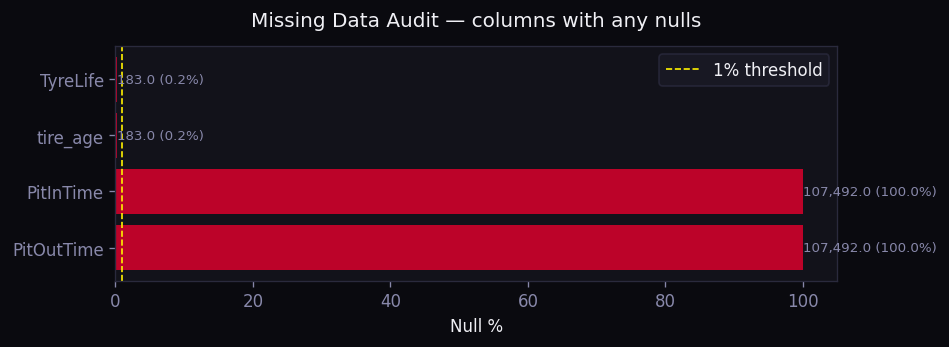


Columns with nulls:
            null_count  null_pct
PitOutTime      107492    100.00
PitInTime       107492    100.00
tire_age           183      0.17
TyreLife           183      0.17

All other columns: 0 nulls ✓


In [2]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_pct    = (null_counts / len(df) * 100).round(2)
audit = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
audit = audit[audit['null_count'] > 0]

fig, ax = plt.subplots(figsize=(8, max(3, len(audit) * 0.4)))
bars = ax.barh(audit.index, audit['null_pct'], color='#E8002D', alpha=0.8)
ax.set_xlabel('Null %')
ax.set_title('Missing Data Audit — columns with any nulls', pad=12)
ax.axvline(1, color='#FFF200', linestyle='--', linewidth=1, label='1% threshold')
ax.legend()
for bar, (_, row) in zip(bars, audit.iterrows()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{row['null_count']:,} ({row['null_pct']:.1f}%)",
            va='center', fontsize=8, color='#8888aa')
plt.tight_layout()
plt.show()

print('\nColumns with nulls:')
print(audit.to_string())
print('\nAll other columns: 0 nulls ✓')

---
## 2. Compound Usage Frequency

**What to look for:** HARD should dominate (long stints), MEDIUM second, SOFT lowest of the dry compounds. INTERMEDIATE and WET should be a small fraction (~5%).  
**Red flag:** If SOFT > HARD, something is wrong with compound assignment or the cleaning step.

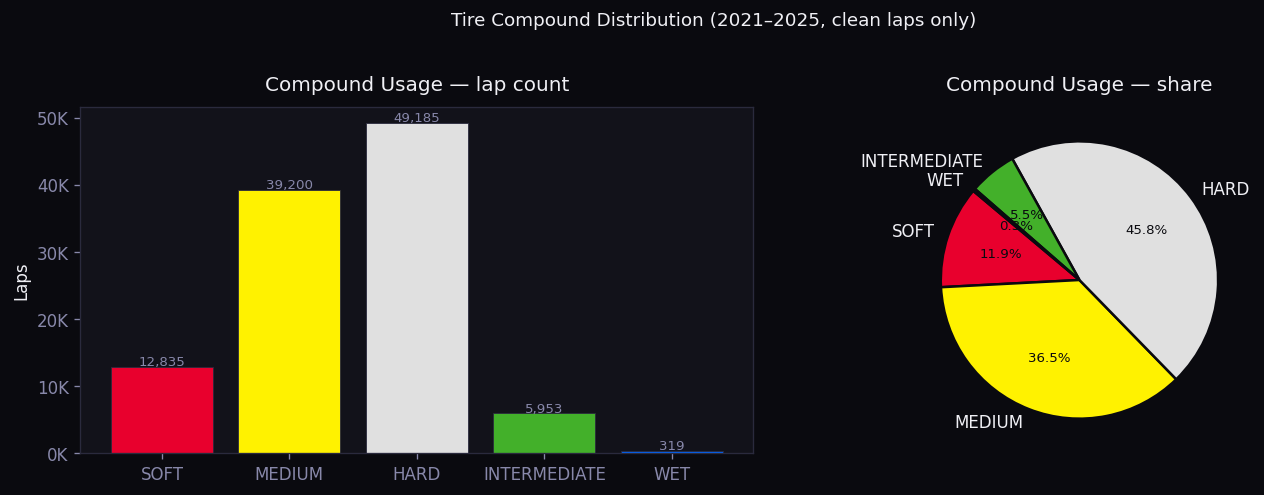

In [3]:
compound_order = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']
counts = df['Compound'].value_counts().reindex(compound_order).dropna()
colors = [COMPOUND_COLORS[c] for c in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='#2a2a3d', linewidth=0.5)
axes[0].set_title('Compound Usage — lap count', pad=10)
axes[0].set_ylabel('Laps')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=8, color='#8888aa')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': '#0a0a0f', 'linewidth': 1.5}
)
for t in autotexts:
    t.set_color('#0a0a0f')
    t.set_fontsize(8)
axes[1].set_title('Compound Usage — share', pad=10)

plt.suptitle('Tire Compound Distribution (2021–2025, clean laps only)', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. Tire Degradation Curves

**Methodology:** Absolute `LapTimeCorrected` vs tire age, filtered to controlled conditions: stint 1 only (controls fuel load), top-10 finishers only (controls driver pace and traffic), green-flag laps only (median + 3σ cutoff per circuit/compound), minimum 10 laps per tire_age bucket.

**Known limitations — why these curves are hard to interpret:**
- **Tire warm-up (laps 1–5):** Cold tires in the first few laps appear artificially slow. As the tire comes into its thermal window (laps 3–8), lap times improve — which shows up as a downward slope at the start of the curve, not real performance gain.
- **Traffic clearing:** In stint 1, cars ahead pit progressively. Drivers gain clean air over laps 10–20, which looks like negative degradation but is actually improving conditions.
- **Compound-allocation bias:** Pirelli allocates specific compound blends per circuit, and teams converge on a single stint-1 compound. Most circuits show only one compound with enough coverage to plot (Bahrain = Soft, Monza/Singapore = Medium). This is real strategy signal, not a data error.

**Conclusion:** The Belgian GP shows the clearest upward trend (best-controlled sample). The XGBoost model in Phase 3 will learn tire degradation directly from raw features (`tire_age`, `compound`, `stint_number`) rather than from this aggregate view — where the confounds above are naturally handled by the model's ability to condition on lap-level context. If Phase 3 MAE is poor on high-deg circuits, revisit these confounds explicitly.

Laps after filter (stint 1 | top-10 finishers | green flag):
  Monaco          994 laps  |  Soft 25b / Medium 11b / Hard 13b
  Italian        1211 laps  |  Soft 0b / Medium 26b / Hard 0b
  Belgian         274 laps  |  Soft 0b / Medium 10b / Hard 0b
  Bahrain         556 laps  |  Soft 15b / Medium 0b / Hard 0b
  Singapore       748 laps  |  Soft 0b / Medium 24b / Hard 0b


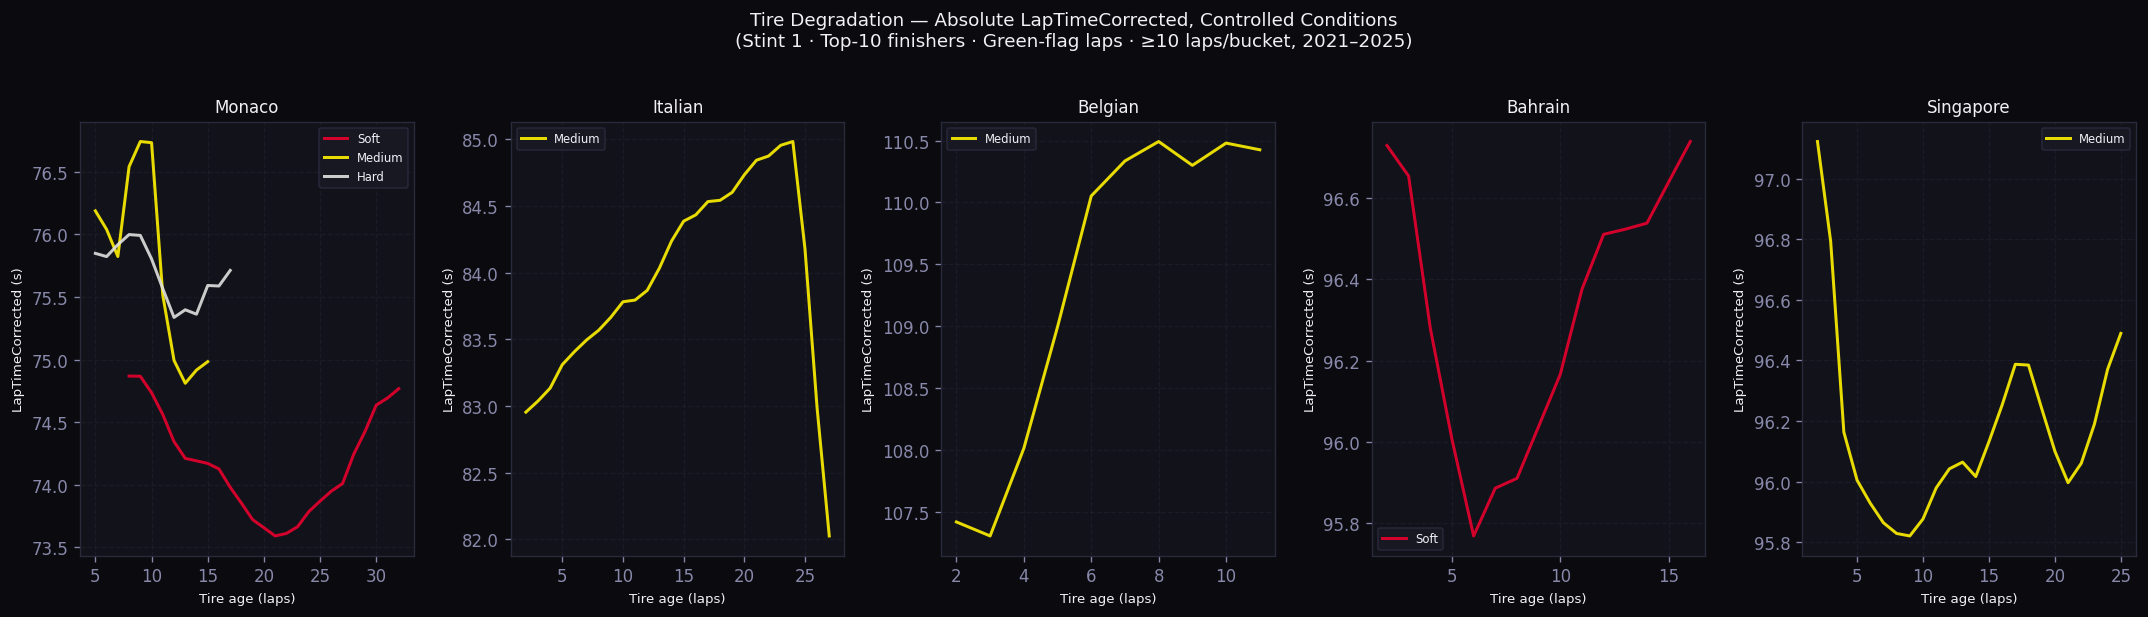

In [4]:
CIRCUITS = [
    'Monaco Grand Prix',
    'Italian Grand Prix',
    'Belgian Grand Prix',
    'Bahrain Grand Prix',
    'Singapore Grand Prix',
]
DRY_COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']
MAX_TIRE_AGE  = 40
MIN_BUCKET    = 10  # minimum laps per (compound, tire_age) bin to plot

# --- Top-10 finishers per race (final lap's track position as finishing position proxy) ---
last_laps = (df.sort_values('LapNumber')
               .groupby(['Year', 'RoundNumber', 'Driver'])
               .last()
               .reset_index()[['Year', 'RoundNumber', 'Driver', 'position']])
top10_keys = last_laps[last_laps['position'] <= 10][['Year', 'RoundNumber', 'Driver']]
top10_keys = top10_keys.copy()
top10_keys['_top10'] = True
df = df.merge(top10_keys, on=['Year', 'RoundNumber', 'Driver'], how='left')
df['_top10'] = df['_top10'].fillna(False)

# --- Green-flag filter: drop laps slower than median + 3σ per (circuit, compound) ---
thresholds = (df.groupby(['EventName', 'Compound'])['LapTimeCorrected']
                .agg(lt_median='median', lt_std='std')
                .reset_index())
df = df.merge(thresholds, on=['EventName', 'Compound'], how='left')
df['_green'] = df['LapTimeCorrected'] <= (df['lt_median'] + 3 * df['lt_std'])

# --- Apply all controlled-condition filters ---
df_ctrl = df[
    (df['Stint'] == 1) &
    df['_top10'] &
    df['_green'] &
    df['LapTimeCorrected'].notna() &
    df['tire_age'].notna()
]

print('Laps after filter (stint 1 | top-10 finishers | green flag):')
for circuit in CIRCUITS:
    short = circuit.replace(' Grand Prix', '')
    sub = df_ctrl[(df_ctrl['EventName'] == circuit) & df_ctrl['Compound'].isin(DRY_COMPOUNDS)]
    n_total = len(sub)
    bucket_summary = []
    for compound in DRY_COMPOUNDS:
        c_data = sub[sub['Compound'] == compound]
        bucket_n = c_data.groupby('tire_age')['LapTimeCorrected'].count()
        n_buckets = (bucket_n >= MIN_BUCKET).sum()
        bucket_summary.append(f'{compound.capitalize()} {n_buckets}b')
    print(f'  {short:<12}  {n_total:>5} laps  |  {" / ".join(bucket_summary)}')

fig, axes = plt.subplots(1, len(CIRCUITS), figsize=(18, 5), sharey=False)

for ax, circuit in zip(axes, CIRCUITS):
    sub = df_ctrl[
        (df_ctrl['EventName'] == circuit) &
        (df_ctrl['Compound'].isin(DRY_COMPOUNDS)) &
        (df_ctrl['tire_age'] <= MAX_TIRE_AGE)
    ]

    for compound in DRY_COMPOUNDS:
        c_data = sub[sub['Compound'] == compound]
        bucket_n = c_data.groupby('tire_age')['LapTimeCorrected'].count()
        valid_ages = bucket_n[bucket_n >= MIN_BUCKET].index
        c_filtered = c_data[c_data['tire_age'].isin(valid_ages)]
        if len(c_filtered) < MIN_BUCKET:
            continue
        curve = (c_filtered.groupby('tire_age')['LapTimeCorrected']
                            .median()
                            .rolling(3, center=True, min_periods=1)
                            .mean())
        ax.plot(curve.index, curve.values,
                color=COMPOUND_COLORS[compound], linewidth=1.8,
                label=compound.capitalize(), alpha=0.9)

    short_name = circuit.replace(' Grand Prix', '')
    ax.set_title(short_name, fontsize=10)
    ax.set_xlabel('Tire age (laps)', fontsize=8)
    ax.set_ylabel('LapTimeCorrected (s)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)

plt.suptitle(
    'Tire Degradation — Absolute LapTimeCorrected, Controlled Conditions\n'
    '(Stint 1 · Top-10 finishers · Green-flag laps · ≥10 laps/bucket, 2021–2025)',
    y=1.02, fontsize=11
)
plt.tight_layout()
plt.show()

---
## 4. Lap Time Distributions Per Circuit

**What to look for:** Monaco should show the slowest median lap time (~75s), Monza the fastest (~84s). Distribution spread reflects how much track position/traffic affects individual laps. Outliers at the top are laps behind safety cars — these should be rare given we dropped `IsAccurate=False` laps.  
**Red flag:** Any circuit with lap times below 50s or above 200s — those would be unit errors or corrupt laps that slipped through cleaning.

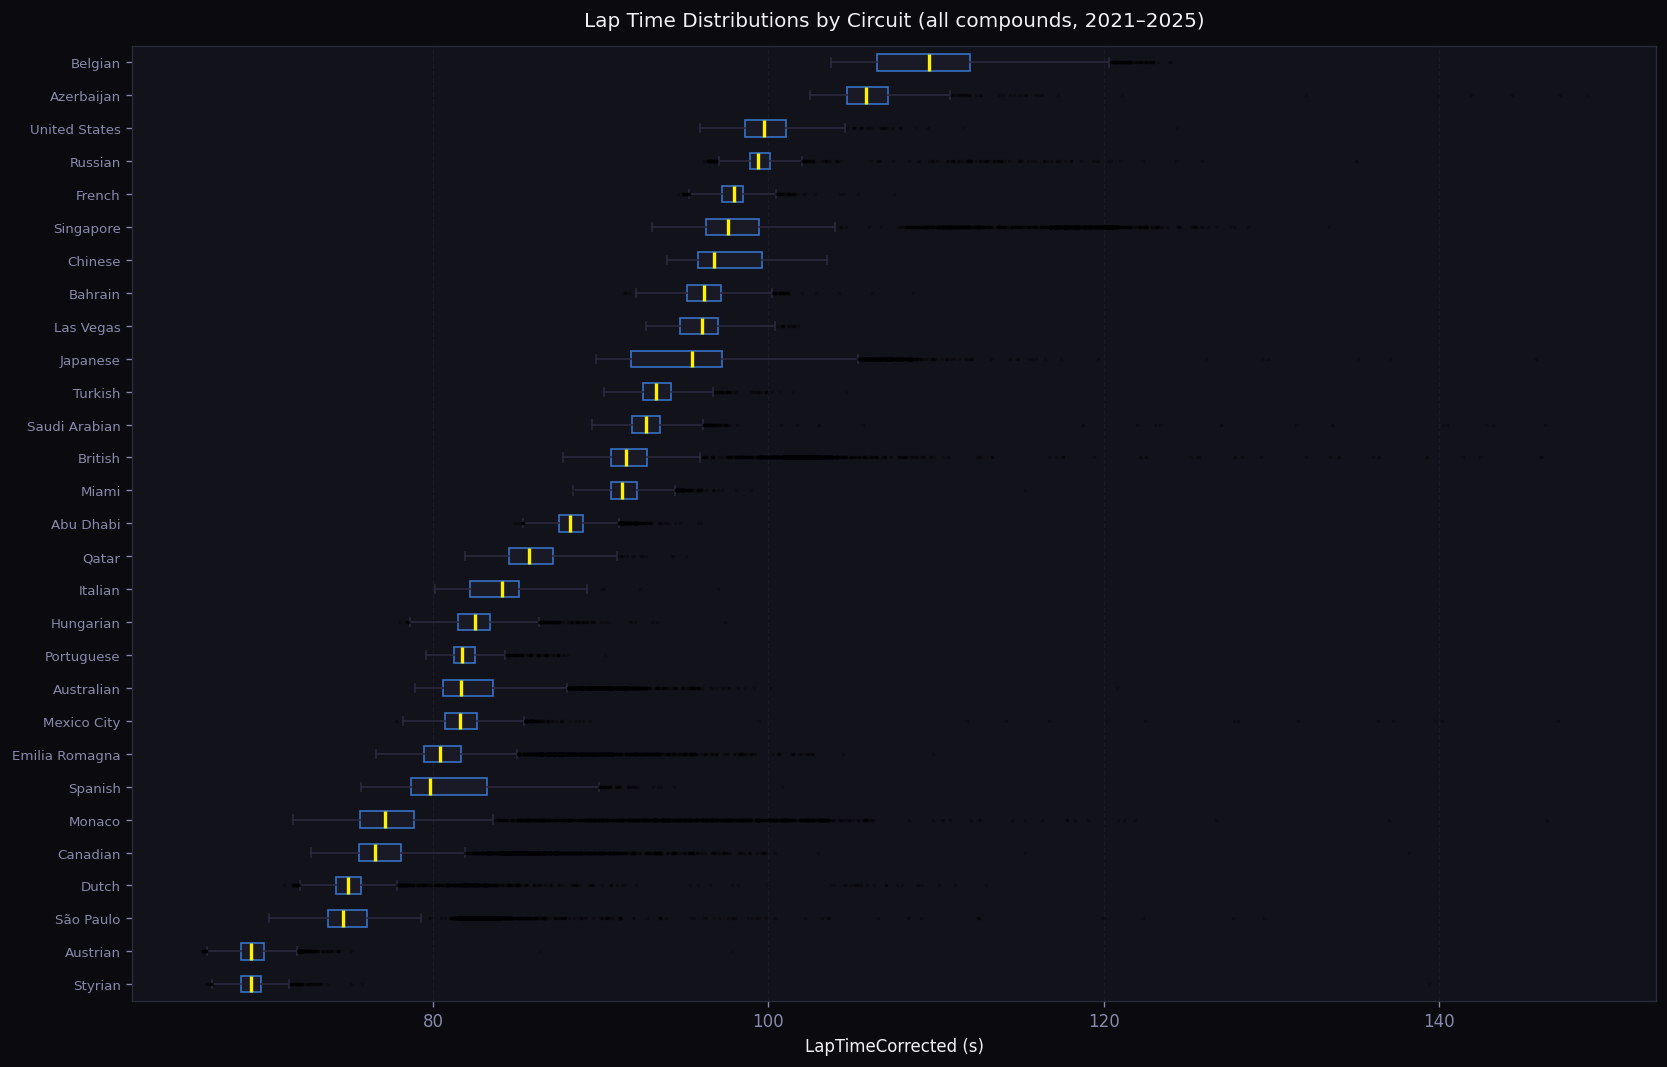

In [5]:
# Show all circuits, sorted by median lap time
circuit_medians = (df.groupby('EventName')['LapTimeCorrected']
                     .median()
                     .sort_values())

fig, ax = plt.subplots(figsize=(14, 9))

data_by_circuit = [
    df.loc[df['EventName'] == c, 'LapTimeCorrected'].dropna().values
    for c in circuit_medians.index
]
short_names = [c.replace(' Grand Prix', '') for c in circuit_medians.index]

bp = ax.boxplot(
    data_by_circuit,
    vert=False,
    patch_artist=True,
    flierprops=dict(marker='.', markersize=2, alpha=0.3, color='#E8002D'),
    medianprops=dict(color='#FFF200', linewidth=2),
    boxprops=dict(facecolor='#1a1a26', edgecolor='#3671C6'),
    whiskerprops=dict(color='#2a2a3d'),
    capprops=dict(color='#2a2a3d'),
)

ax.set_yticks(range(1, len(short_names) + 1))
ax.set_yticklabels(short_names, fontsize=8)
ax.set_xlabel('LapTimeCorrected (s)')
ax.set_title('Lap Time Distributions by Circuit (all compounds, 2021–2025)', pad=12)
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

---
## 5. Wet vs Dry Lap Time Delta

**Methodology — compound-based wet indicator:**  
The `is_wet` column is a session-level flag (`True` if any rain occurred during the session). In practice this means a race with a brief shower flags *all* laps as wet — including the majority run on dry tyres in fully dry conditions. This contaminates the wet sample with fast dry laps, artificially compressing the wet penalty.

Instead, we use the actual tyre compound as the wet indicator: laps on INTERMEDIATE or WET tyres are genuinely wet laps. Laps on SOFT/MEDIUM/HARD are dry laps. This gives a clean like-for-like comparison.

**What to look for:** Wet laps (intermediates/full wets) should be 5–20s slower than dry laps at the same circuit. Circuits with long straights (Spa, Monza) tend to show smaller per-lap penalties; tight twisty circuits (Monaco, Singapore) show larger ones.  
**Red flag:** Wet laps faster than dry — would indicate incorrect compound assignment in FastF1.

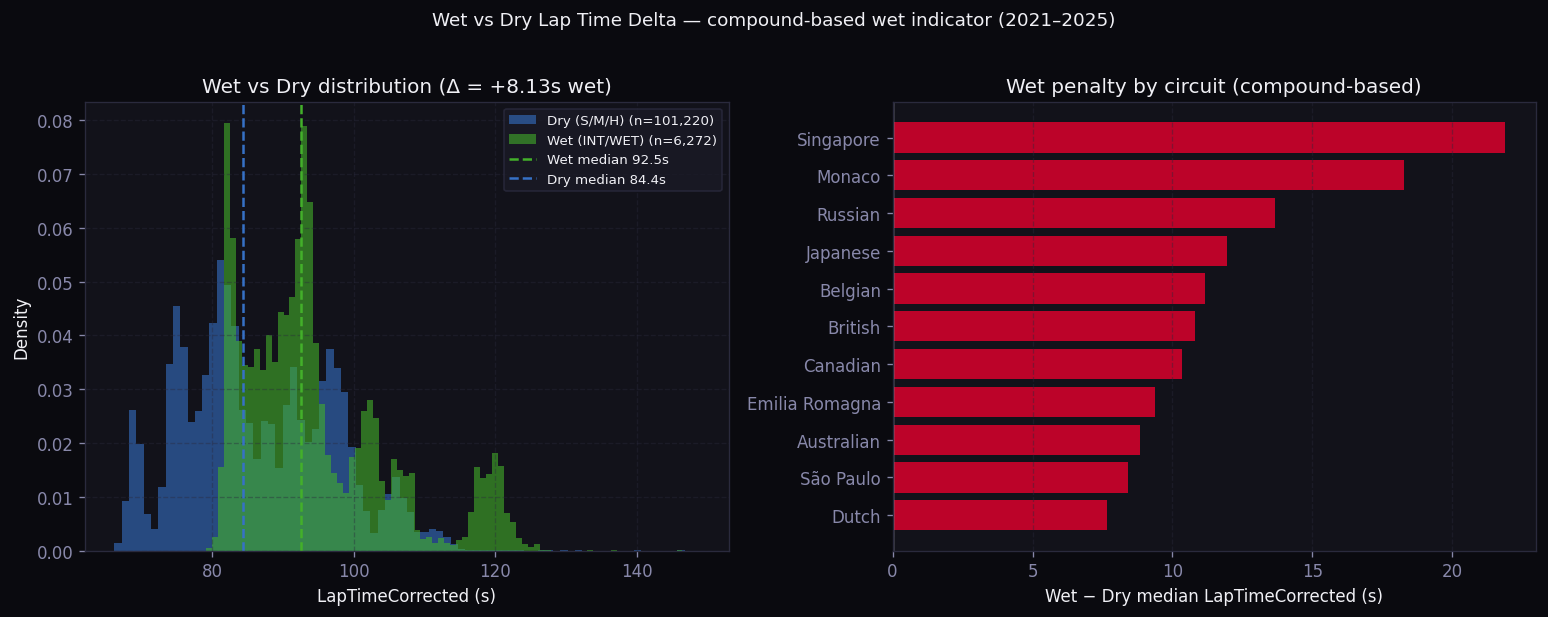


Overall wet penalty (INT/WET vs S/M/H): +8.13s
Wet laps: 6,272 | Dry laps: 101,220

Per-circuit delta (s):
EventName
Dutch Grand Prix              7.66
São Paulo Grand Prix          8.41
Australian Grand Prix         8.83
Emilia Romagna Grand Prix     9.39
Canadian Grand Prix          10.36
British Grand Prix           10.81
Belgian Grand Prix           11.16
Japanese Grand Prix          11.93
Russian Grand Prix           13.68
Monaco Grand Prix            18.29
Singapore Grand Prix         21.90


In [6]:
WET_COMPOUNDS = ['INTERMEDIATE', 'WET']

wet_laps = df[df['Compound'].isin(WET_COMPOUNDS) & df['LapTimeCorrected'].notna()]
dry_laps = df[df['Compound'].isin(DRY_COMPOUNDS) & df['LapTimeCorrected'].notna()]

wet_med = wet_laps['LapTimeCorrected'].median()
dry_med = dry_laps['LapTimeCorrected'].median()
delta   = wet_med - dry_med

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall distribution
for laps, label, color in [
    (dry_laps, 'Dry (S/M/H)',    '#3671C6'),
    (wet_laps, 'Wet (INT/WET)',  '#43B02A'),
]:
    axes[0].hist(laps['LapTimeCorrected'], bins=80, alpha=0.6, color=color,
                 label=f'{label} (n={len(laps):,})', density=True)
axes[0].axvline(wet_med, color='#43B02A', linestyle='--', linewidth=1.5, label=f'Wet median {wet_med:.1f}s')
axes[0].axvline(dry_med, color='#3671C6', linestyle='--', linewidth=1.5, label=f'Dry median {dry_med:.1f}s')
axes[0].set_xlabel('LapTimeCorrected (s)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Wet vs Dry distribution (Δ = +{delta:.2f}s wet)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

# Per-circuit wet delta — only circuits that have both wet and dry laps
combined = pd.concat([
    dry_laps[['EventName', 'LapTimeCorrected']].assign(kind='dry'),
    wet_laps[['EventName', 'LapTimeCorrected']].assign(kind='wet'),
])
circuit_delta = (combined.groupby(['EventName', 'kind'])['LapTimeCorrected']
                          .median()
                          .unstack('kind')
                          .dropna())
circuit_delta['delta'] = circuit_delta['wet'] - circuit_delta['dry']
circuit_delta = circuit_delta.sort_values('delta', ascending=True)

colors_bar = ['#E8002D' if d > 0 else '#3671C6' for d in circuit_delta['delta']]
short = [c.replace(' Grand Prix', '') for c in circuit_delta.index]
axes[1].barh(short, circuit_delta['delta'], color=colors_bar, alpha=0.8)
axes[1].axvline(0, color='#f0f0f5', linewidth=0.8)
axes[1].set_xlabel('Wet − Dry median LapTimeCorrected (s)')
axes[1].set_title('Wet penalty by circuit (compound-based)')
axes[1].grid(True, axis='x', alpha=0.4)

plt.suptitle('Wet vs Dry Lap Time Delta — compound-based wet indicator (2021–2025)', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print(f'\nOverall wet penalty (INT/WET vs S/M/H): +{delta:.2f}s')
print(f'Wet laps: {len(wet_laps):,} | Dry laps: {len(dry_laps):,}')
print(f'\nPer-circuit delta (s):')
print(circuit_delta['delta'].round(2).to_string())

---
## 6. Train / Val / Test Split Summary

**What to look for:** Row counts and race distribution should match expectations — 89 train races (2021–2024), 12 val (2025 H1), 12 test (2025 H2). The split is by race, so no lap from a given race weekend appears in more than one split.  
**Red flag:** Any race appearing in two splits — that's data leakage.

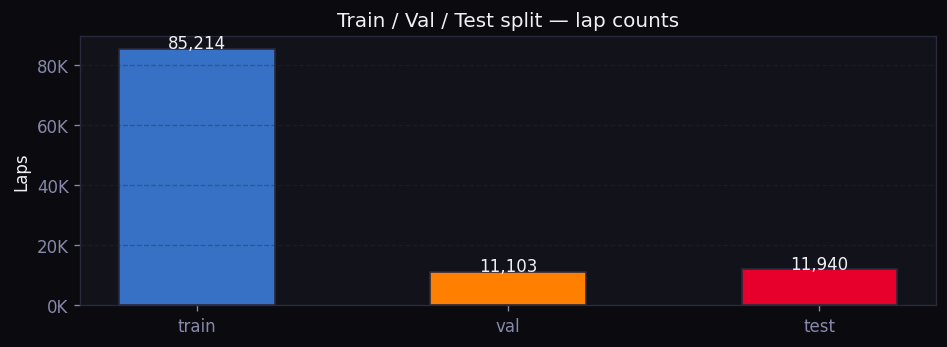


Detailed summary:
  train      85,214 laps   89 races  2021–2024
  val        11,103 laps   12 races  2025
  test       11,940 laps   12 races  2025


In [7]:
from pitiq.features.split import split_features

splits = split_features()

fig, ax = plt.subplots(figsize=(8, 3))
names  = list(splits.keys())
counts = [len(v) for v in splits.values()]
colors = ['#3671C6', '#FF8000', '#E8002D']
bars   = ax.bar(names, counts, color=colors, edgecolor='#2a2a3d', width=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{cnt:,}', ha='center', fontsize=10)
ax.set_ylabel('Laps')
ax.set_title('Train / Val / Test split — lap counts')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print('\nDetailed summary:')
for name, sdf in splits.items():
    years  = sorted(sdf['Year'].unique())
    races  = sdf.groupby(['Year','RoundNumber']).ngroups
    yr_str = f"{years[0]}–{years[-1]}" if len(years) > 1 else str(years[0])
    print(f"  {name:<8} {len(sdf):>8,} laps  {races:>3} races  {yr_str}")